# Basic Simple Linear Regression Project Analysis 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [ ]:
# Reading the dataset as: 

df = pd.read_csv('height-weight.csv') 
df  

# The whole dataset has been presented here 

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [3]:
df.shape

(23, 2)

In [4]:
# Presenting the top 5 rows of the whole dataset as: 
df.head() 

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

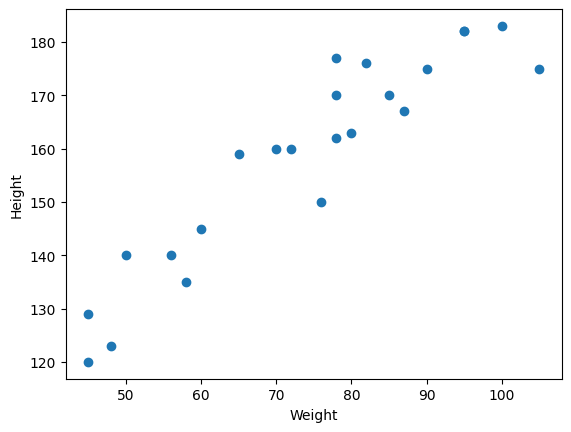

In [ ]:
# Now, making the scatter plot for the properpresentation as: 

plt.scatter(df['Weight'], df['Height']) 
plt.xlabel("Weight") 
plt.ylabel("Height")  

# Here, the scatter plot has been plotted properly 

Now, here we have to divide our dataset into the dependent and the independent features as Height and Weight which goes on as: 

In [6]:
x = df[['Weight']] # Independent Features 
y = df[['Height']]  # Dependent Features 

In [7]:
x 

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [8]:
y 

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [9]:
# Now, by applying the train test split, it goes on as: 
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42) 

In [ ]:
# Now, calculating the shapes of all follows as: 

x_train.shape, y_train.shape, x_test.shape, y_test.shape  

# Here, is the difference in the amount of data taken for training and testing 

((17, 1), (17, 1), (6, 1), (6, 1))

In [12]:
# Now, standardiing the dataset into the independent features as: 

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()  

scaler 

,copy,True
,with_mean,True
,with_std,True


In [13]:
x_train = scaler.fit_transform(x_train) 
x_train 

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [14]:
x_test = scaler.transform(x_test) 
x_test 

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

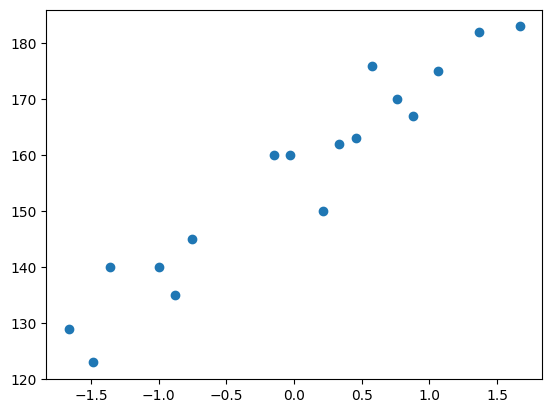

In [15]:
# Now, plotting the scatter plot goes as: 
plt.scatter(x_train, y_train) 


Now, comes the training of the simple linear regressor model goes as: 



In [17]:
from sklearn.linear_model import LinearRegression  

regressor = LinearRegression() 
regressor 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
regressor.fit(x_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
print("The slope or the coefficient of weight is: ", regressor.coef_) 
print("Intercept: ", regressor.intercept_) 

The slope or the coefficient of weight is:  [[17.2982057]]
Intercept:  [156.47058824]


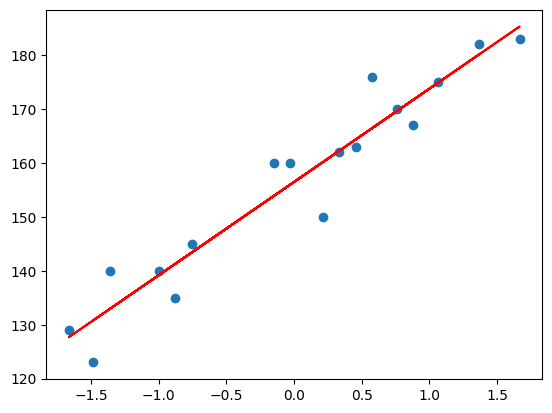

In [20]:
# Now, plotting the correcct graph takes place as; 

plt.scatter(x_train, y_train) 
plt.plot(x_train, regressor.predict(x_train), color = 'r') 

# Prediction of the train data 

1. predicted height output = intercept + coef_(weights) 
2. y_pred_train = 157.5 + 17.03(x_train)  

# Prediction of test data 

1. predicted height output = intercept + coef_(Weights) 
2. y_pred_test = 157.5 + 17.03(x_test) 

In [21]:
y_pred = regressor.predict(x_test) 
y_pred 

array([[162.26499721],
       [162.26499721],
       [127.68347133],
       [180.07972266],
       [148.64197186],
       [190.55897293]])

In [22]:
y_pred, y_test 

(array([[162.26499721],
        [162.26499721],
        [127.68347133],
        [180.07972266],
        [148.64197186],
        [190.55897293]]),
     Height
 15     177
 9      170
 0      120
 8      182
 17     159
 12     175)

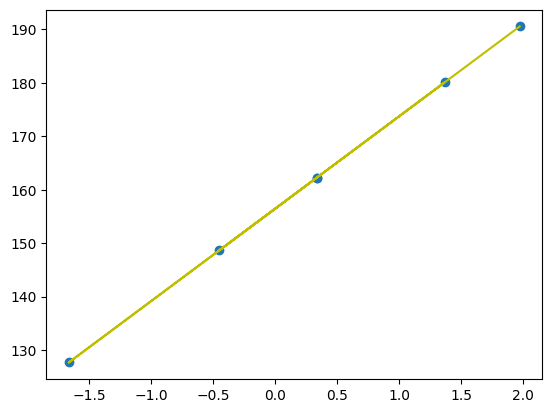

In [24]:
plt.scatter(x_test, y_pred) 
plt.plot(x_test, regressor.predict(x_test), color = 'y') 

# Performance Metrics  

# MSE, MAE, RMSE  



In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error 


In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)  

rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


# R Square 

Formula :  R^2 = 1 - SSR/SST 

R^2 = coefficient of determination 
SSR = sum of squares of residuals 
SST = total sum of squares 

In [28]:
from sklearn.metrics import r2_score 
score = r2_score(y_test, y_pred)  

score 

0.7360826717981276

# Adjustd R square  

Adjusted R2 = 1 - 1 – [(1-R2)*(n-1)/(n-k-1)] 

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables 

In [29]:
# Display the adjusted r square 

1 - (1 - score)*(len(y_test) - 1)/(len(y_test) - x_test.shape[1] - 1) 

0.6701033397476595

In [30]:
# New data point weight is 80 

scaled_weight = scaler.transform([[80]]) 
scaled_weight 

c:\Users\91981\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.45613165]])

In [31]:
scaled_weight[0]

array([0.45613165])

In [32]:
print("The height predicted for the weight 80 kg is: ", regressor.predict([scaled_weight[0]])) 

The height predicted for the weight 80 kg is:  [[164.36084726]]


In [33]:
# Residuals 
residuals = y_test - y_pred  
residuals 

,Height
15,14.735003
9,7.735003
0,-7.683471
8,1.920277
17,10.358028
12,-15.558973


C:\Users\91981\AppData\Local\Temp\ipykernel_35480\2380587152.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde = True)


<Axes: ylabel='Density'>

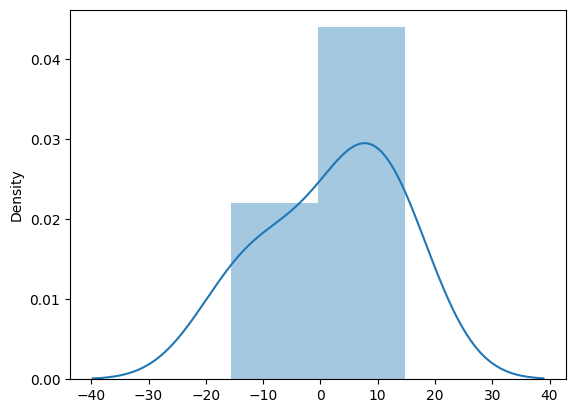

In [35]:
# plotting of the residuals 

sns.distplot(residuals, kde = True) 

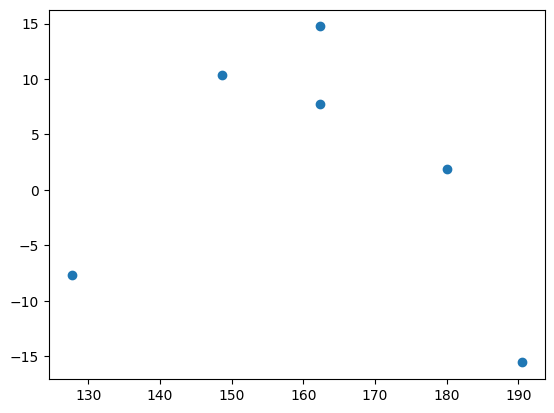

In [36]:
# Scatter plot of y_pred and residuals 

plt.scatter(y_pred, residuals)